# LightGBM Threshold Tuning — Notebook

This notebook loads the trained LightGBM model and sweeps classification thresholds
to find the one that maximizes F1-score, then visualizes the tradeoff between
precision, recall, and F1 across thresholds.

Run `08_train_lightgbm_model_colab.ipynb` first so the model file exists, then run
this notebook top to bottom.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

print("Imports OK")

Imports OK


## 1. Configure paths

The original script used paths relative to the current working directory. In Colab,
the working directory usually isn't your project root, so this notebook auto-detects
the workspace root the same way the other training notebooks do. Update
`WORKSPACE_ROOT` manually below if needed (e.g. pointing at a mounted Drive folder).

In [2]:
def find_workspace_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for path in [current, *current.parents]:
        if (path / "data" / "processed" / "baseline_modeling_dataset.csv.gz").exists():
            return path

    return current


WORKSPACE_ROOT = find_workspace_root()

# --- If auto-detection doesn't find your dataset (common in Colab), set it manually: ---
# WORKSPACE_ROOT = Path("/content/drive/MyDrive/your-project-folder")

DATASET_FILE = WORKSPACE_ROOT / "data" / "processed" / "baseline_modeling_dataset.csv.gz"
MODEL_FILE = WORKSPACE_ROOT / "ml" / "model_artifacts" / "lightgbm_fraud_model.joblib"
REPORTS_DIR = WORKSPACE_ROOT / "reports" / "model_reports"
FIGURES_DIR = WORKSPACE_ROOT / "reports" / "figures"
THRESHOLD_RESULTS_FILE = REPORTS_DIR / "lightgbm_threshold_tuning.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2

print(f"WORKSPACE_ROOT: {WORKSPACE_ROOT}")
print(f"DATASET_FILE:   {DATASET_FILE}  (exists: {DATASET_FILE.exists()})")
print(f"MODEL_FILE:     {MODEL_FILE}  (exists: {MODEL_FILE.exists()})")

WORKSPACE_ROOT: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai
DATASET_FILE:   C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\data\processed\baseline_modeling_dataset.csv.gz  (exists: True)
MODEL_FILE:     C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\ml\model_artifacts\lightgbm_fraud_model.joblib  (exists: True)


In [3]:
def create_output_directories() -> None:
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)


create_output_directories()
print("Output directories ready:")
for d in [REPORTS_DIR, FIGURES_DIR]:
    print(f"  - {d}")

Output directories ready:
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures


## 2. Load the dataset

In [4]:
def load_dataset() -> tuple[pd.DataFrame, pd.Series]:
    if not DATASET_FILE.exists():
        raise FileNotFoundError(
            f"Processed dataset not found: {DATASET_FILE}. "
            "Run ml/src/features/build_baseline_feature_dataset.py first."
        )

    df = pd.read_csv(DATASET_FILE)
    target = df["isFraud"]
    features = df.drop(columns=["isFraud"])
    return features, target


features, target = load_dataset()
print(f"Features shape: {features.shape}")
print(f"Target shape:   {target.shape}")
print(f"Fraud rate:     {target.mean():.4%}")

Features shape: (590540, 81)
Target shape:   (590540,)
Fraud rate:     3.4990%


## 3. Recreate the test split

Uses the same `random_state` and `test_size` as training, so this reproduces the
exact held-out test set the model was evaluated on.

In [5]:
_, X_test, _, y_test = train_test_split(
    features,
    target,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target,
)

print(f"X_test: {X_test.shape}   y_test fraud rate: {y_test.mean():.4%}")

X_test: (118108, 81)   y_test fraud rate: 3.4993%


## 4. Load the trained LightGBM model

In [6]:
def load_model():
    if not MODEL_FILE.exists():
        raise FileNotFoundError(
            f"LightGBM model not found: {MODEL_FILE}. "
            "Run ml/src/models/train_lightgbm_model.py first."
        )
    return joblib.load(MODEL_FILE)


model = load_model()
print(f"Model loaded from: {MODEL_FILE}")
print(f"Model type: {type(model).__name__}")
print("Pipeline steps:", list(model.named_steps.keys()))

Model loaded from: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\ml\model_artifacts\lightgbm_fraud_model.joblib
Model type: Pipeline
Pipeline steps: ['preprocessor', 'classifier']


In [7]:
y_proba = model.predict_proba(X_test)[:, 1]
print(f"Predicted probabilities generated for {len(y_proba)} test samples.")
print(f"Min: {y_proba.min():.4f}   Max: {y_proba.max():.4f}   Mean: {y_proba.mean():.4f}")

c:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Predicted probabilities generated for 118108 test samples.
Min: 0.0010   Max: 0.9990   Mean: 0.2302


## 5. Sweep classification thresholds

In [8]:
def evaluate_thresholds(y_true: pd.Series, y_proba: np.ndarray) -> pd.DataFrame:
    thresholds = np.arange(0.05, 0.96, 0.01)
    records = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        records.append(
            {
                "threshold": round(float(threshold), 2),
                "accuracy": accuracy_score(y_true, y_pred),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1_score": f1_score(y_true, y_pred, zero_division=0),
                "predicted_fraud_count": int(y_pred.sum()),
            }
        )
    return pd.DataFrame(records)


threshold_df = evaluate_thresholds(y_test, y_proba)
threshold_df.to_csv(THRESHOLD_RESULTS_FILE, index=False)
print(f"Threshold tuning results saved to: {THRESHOLD_RESULTS_FILE}")
print(f"Evaluated {len(threshold_df)} thresholds.")
threshold_df.head(10)

Threshold tuning results saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\lightgbm_threshold_tuning.csv
Evaluated 91 thresholds.


,threshold,accuracy,precision,recall,f1_score,predicted_fraud_count
0,0.05,0.187049,0.041186,0.997822,0.079107,100131
1,0.06,0.233498,0.043515,0.996371,0.083389,94633
2,0.07,0.279067,0.046068,0.994677,0.088058,89237
3,0.08,0.322154,0.048758,0.992499,0.092949,84130
4,0.09,0.361618,0.051460,0.989112,0.097829,79441
5,0.10,0.397780,0.054241,0.986209,0.102827,75146
6,0.11,0.431554,0.057145,0.983547,0.108014,71135
7,0.12,0.462898,0.060099,0.980160,0.113254,67405
8,0.13,0.491973,0.063216,0.978224,0.118758,63955
9,0.14,0.518695,0.066312,0.975079,0.124180,60773


## 6. Select the best threshold by F1-score

In [9]:
def select_best_threshold(threshold_df: pd.DataFrame) -> pd.Series:
    return threshold_df.loc[threshold_df["f1_score"].idxmax()]


best_threshold_row = select_best_threshold(threshold_df)
best_threshold = float(best_threshold_row["threshold"])
print("Best threshold by F1-score:")
print(best_threshold_row)

Best threshold by F1-score:
threshold                   0.840000
accuracy                    0.974947
precision                   0.678095
recall                      0.540769
f1_score                    0.601696
predicted_fraud_count    3296.000000
Name: 79, dtype: float64


## 7. Chart — precision, recall, and F1 across thresholds

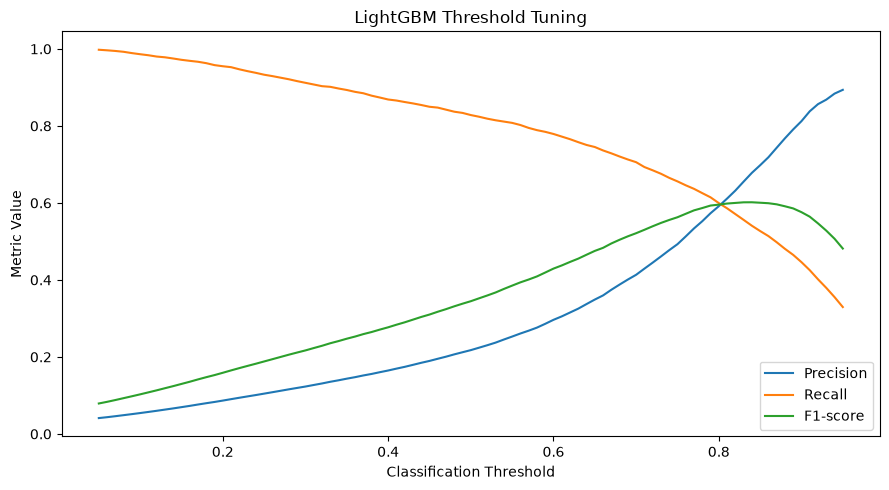

Figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\lightgbm_threshold_metrics.png


In [10]:
def plot_threshold_metrics(threshold_df: pd.DataFrame) -> None:
    plt.figure(figsize=(9, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1-score")
    plt.title("LightGBM Threshold Tuning")
    plt.xlabel("Classification Threshold")
    plt.ylabel("Metric Value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "lightgbm_threshold_metrics.png")
    plt.show()


plot_threshold_metrics(threshold_df)
print(f"Figure saved to: {FIGURES_DIR / 'lightgbm_threshold_metrics.png'}")

## 8. Confusion matrix at the best threshold

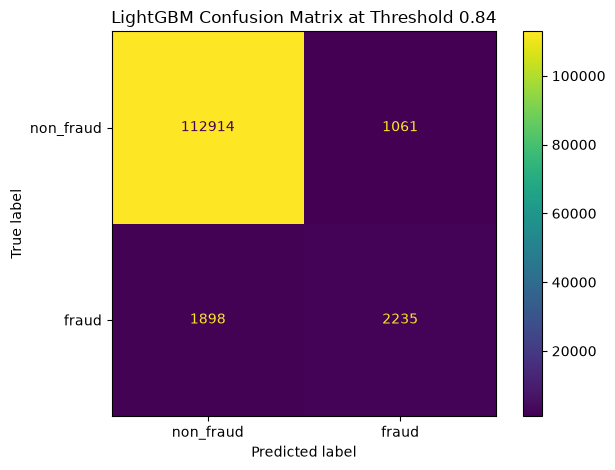

Figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\lightgbm_best_threshold_confusion_matrix.png


In [11]:
def plot_best_threshold_confusion_matrix(
    y_true: pd.Series,
    y_proba: np.ndarray,
    best_threshold: float,
) -> None:
    y_pred = (y_proba >= best_threshold).astype(int)
    matrix = confusion_matrix(y_true, y_pred)
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["non_fraud", "fraud"],
    )
    display.plot(values_format="d")
    plt.title(f"LightGBM Confusion Matrix at Threshold {best_threshold:.2f}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "lightgbm_best_threshold_confusion_matrix.png")
    plt.show()


plot_best_threshold_confusion_matrix(y_test, y_proba, best_threshold)
print(f"Figure saved to: {FIGURES_DIR / 'lightgbm_best_threshold_confusion_matrix.png'}")

## 9. Summary

In [12]:
print("LightGBM Threshold Tuning Report")
print("=" * 80)
print("Best threshold by F1-score:")
print(best_threshold_row)
print()
print("Top 10 thresholds by F1-score:")
print(threshold_df.sort_values("f1_score", ascending=False).head(10))
print()
print("Default threshold 0.50 metrics:")
default_row = threshold_df[threshold_df["threshold"] == 0.50]
print(default_row)
print()
print(f"Threshold tuning results saved to: {THRESHOLD_RESULTS_FILE}")
print(f"Figures saved to: {FIGURES_DIR}")

LightGBM Threshold Tuning Report
Best threshold by F1-score:
threshold                   0.840000
accuracy                    0.974947
precision                   0.678095
recall                      0.540769
f1_score                    0.601696
predicted_fraud_count    3296.000000
Name: 79, dtype: float64

Top 10 thresholds by F1-score:
    threshold  accuracy  precision    recall  f1_score  predicted_fraud_count
79       0.84  0.974947   0.678095  0.540769  0.601696                   3296
78       0.83  0.974227   0.655261  0.556013  0.601571                   3507
80       0.85  0.975463   0.697853  0.526978  0.600496                   3121
77       0.82  0.973355   0.632030  0.571014  0.599975                   3734
81       0.86  0.975946   0.718539  0.513912  0.599238                   2956
76       0.81  0.972474   0.611307  0.586015  0.598394                   3962
82       0.87  0.976411   0.743229  0.497943  0.596349                   2769
75       0.80  0.971501   0.591549  